Step 1: Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load the Dataset

In [2]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

Step 3: View the Dataset

In [3]:
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

Step 4: Check Dataset Information

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB
None


Step 5: Check Missing Values

In [5]:
print(df.isnull().sum())

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


Step 6: Clean Column Names

In [ ]:
df.columns = df.columns.str.strip()

Step 7: Convert Date Column

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_508/2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


Step 8: Display Statistical Summary

In [9]:
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            267                       267.000000   
mean   2020-06-16 09:15:30.337078528                        12.236929   
min              2020-01-31 00:00:00                         0.500000   
25%              2020-03-31 00:00:00                         4.845000   
50%              2020-06-30 00:00:00                         9.650000   
75%              2020-08-31 00:00:00                        16.755000   
max              2020-10-31 00:00:00                        75.850000   
std                              NaN                        10.803283   

       Estimated Employed  Estimated Labour Participation Rate (%)  \
count        2.670000e+02                               267.000000   
mean         1.396211e+07                                41.681573   
min          1.175420e+05                                16.770000   
25%          2.838930e+06                                37.26

Step 9: Calculate Average Unemployment Rate

In [10]:
average_rate = df['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate:")
print(round(average_rate,2))

Average Unemployment Rate:
12.24


Step 10: Plot Unemployment Trend

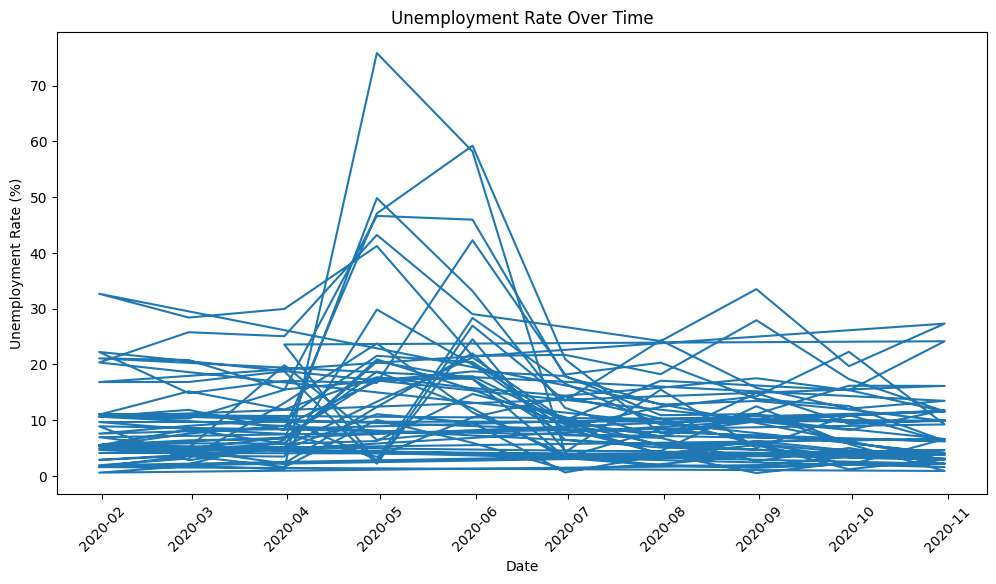

In [39]:
plt.figure(figsize=(12,6))

plt.plot(
    df['Date'],
    df['Estimated Unemployment Rate (%)']
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.show()

Step 11: Average Unemployment by Region

In [12]:
region_data = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

print(region_data)

Region
Andhra Pradesh       8.664000
Assam                4.856000
Bihar               19.471000
Chhattisgarh         7.819000
Delhi               18.414000
Goa                 12.167000
Gujarat              6.376000
Haryana             27.477000
Himachal Pradesh    16.065000
Jammu & Kashmir     16.477778
Jharkhand           19.539000
Karnataka            7.668000
Kerala               9.434000
Madhya Pradesh       6.854000
Maharashtra          7.979000
Meghalaya            3.866000
Odisha               6.462000
Puducherry          17.942000
Punjab              11.981000
Rajasthan           15.868000
Sikkim               9.792500
Tamil Nadu          12.187000
Telangana            6.833000
Tripura             25.055000
Uttar Pradesh        9.737000
Uttarakhand         11.156000
West Bengal         10.192000
Name: Estimated Unemployment Rate (%), dtype: float64


Step 12: Visualize Region-wise Unemployment

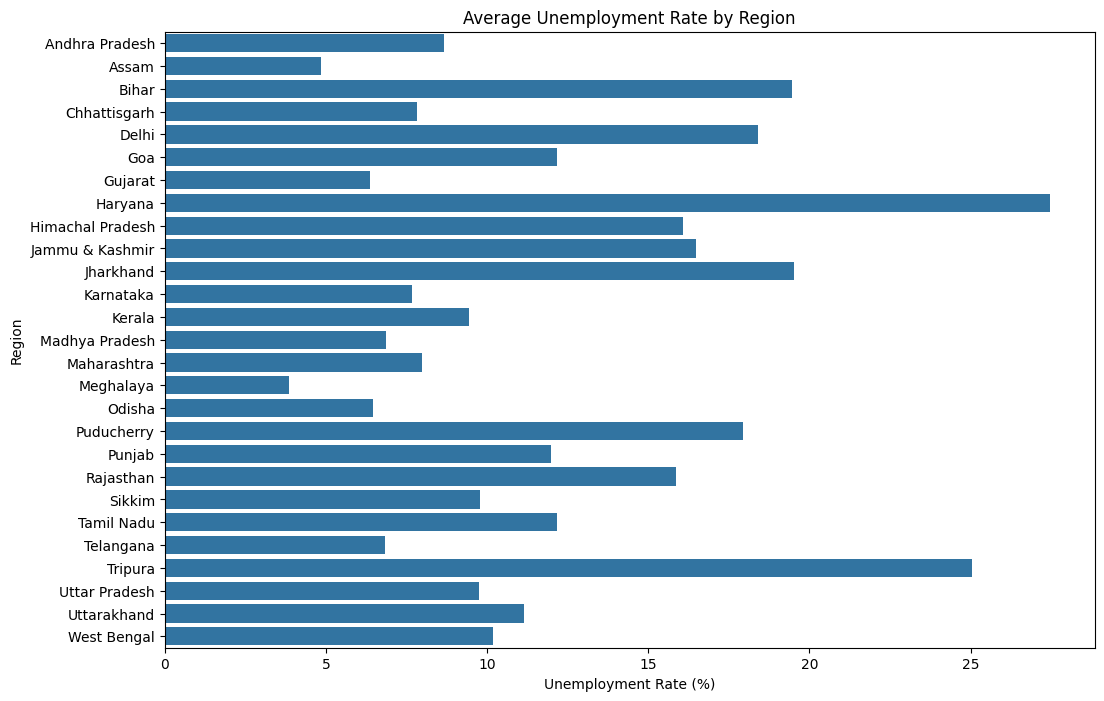

In [13]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=region_data.values,
    y=region_data.index
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Region")

plt.show()

Step 13: Analyze COVID-19 Impact

Before COVID (January–March 2020)

In [14]:
before_covid = df[df['Date'] < '2020-04-01']

print(before_covid['Estimated Unemployment Rate (%)'].mean())

9.761518987341773


During/After COVID (April–November 2020)

In [15]:
after_covid = df[df['Date'] >= '2020-04-01']

print(after_covid['Estimated Unemployment Rate (%)'].mean())

13.277127659574465


Step 14: Create Month Column

In [17]:
df['Month'] = df['Date'].dt.month_name()

Step 15: Monthly Unemployment Analysis

In [18]:
monthly_data = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

print(monthly_data)

Month
April        22.236154
August       10.313333
February      9.266154
January       9.196538
July          9.834444
June         10.911111
March        10.782593
May          23.244444
October       8.026296
September     8.705926
Name: Estimated Unemployment Rate (%), dtype: float64


Step 16: Plot Monthly Trend

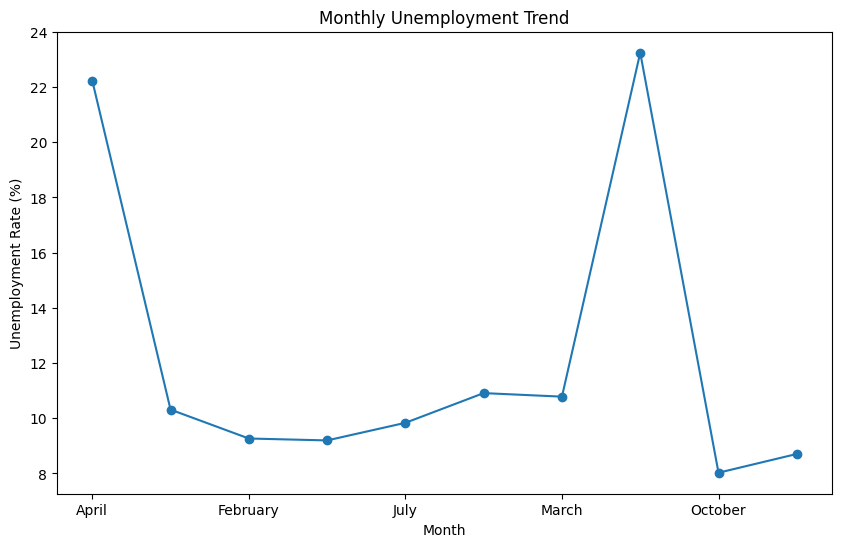

In [19]:
plt.figure(figsize=(10,6))

monthly_data.plot(marker='o')

plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")

plt.show()

Step 17: Labour Participation vs Unemployment

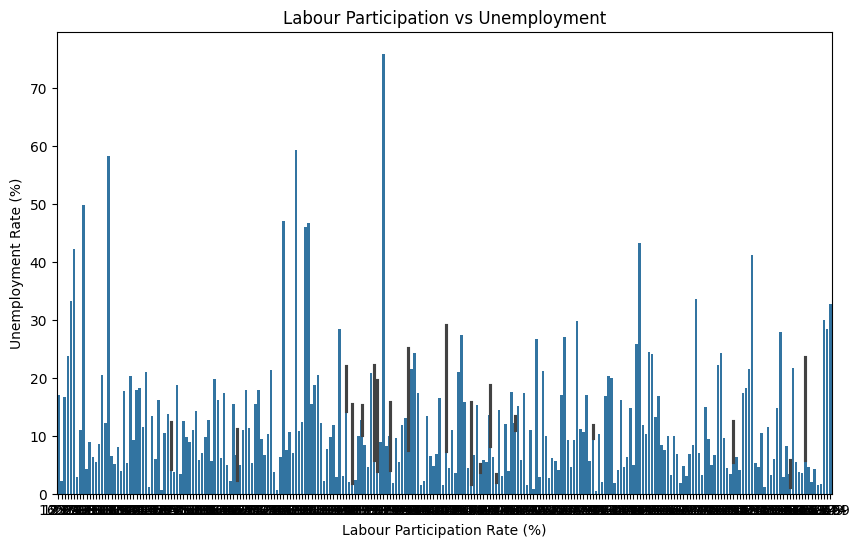

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Labour Participation vs Unemployment")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.show()

Step 18: Correlation Heatmap

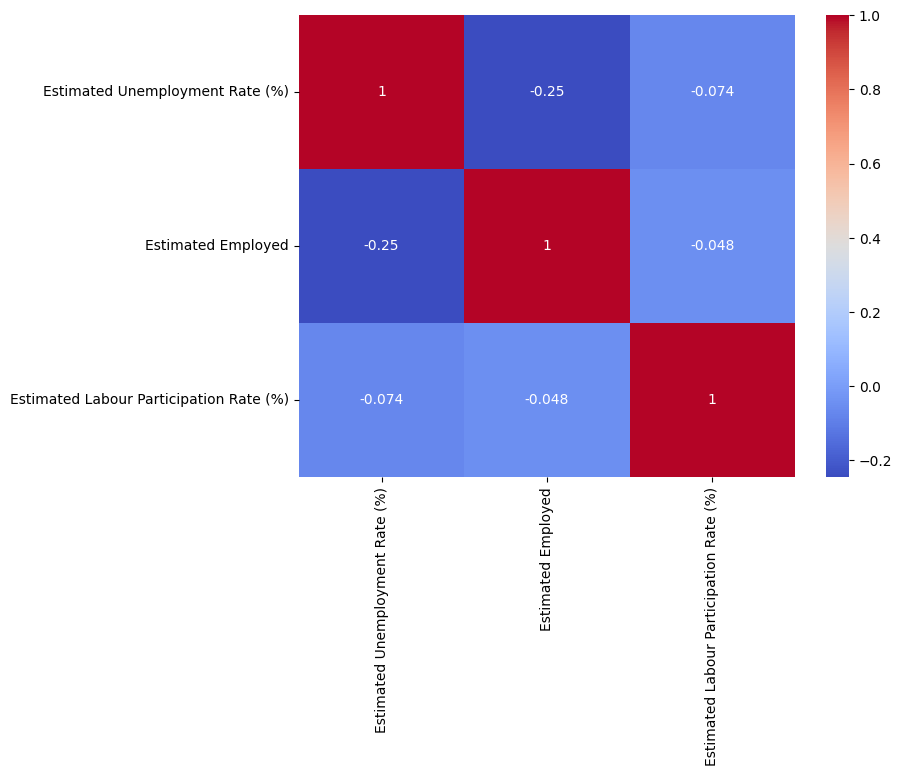

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

Step 19: Print Insights

In [22]:
print("Insights:")
print("1. Unemployment increased significantly during COVID-19.")
print("2. April and May recorded the highest unemployment rates.")
print("3. Regional differences in unemployment were observed.")
print("4. Employment gradually recovered after lockdown.")
print("5. Labour participation changed during the pandemic.")

Insights:
1. Unemployment increased significantly during COVID-19.
2. April and May recorded the highest unemployment rates.
3. Regional differences in unemployment were observed.
4. Employment gradually recovered after lockdown.
5. Labour participation changed during the pandemic.
